# DFU Classification — Project Overview

**Goal**: Classify Diabetic Foot Ulcer (DFU) images into CT (Control=0) and DM (Diabetic=1)  
**Dataset**: INAOE — 334 images (CT=90, DM=244), 224×224 px, normalized [0,1], `.npy` format  
**Framework**: TensorFlow 2.21 + Keras 3  

> **Usage**: Run cells top to bottom. Training (Section 3) runs automatically — already-trained models are skipped.


In [38]:
import sys, os, json, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from PIL import Image

warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

# Always run from the project directory
PROJECT_DIR = Path('/home/ntphoto/Project')
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))

from dfu_common import CONFIG, load_preprocessed_inaoe, create_fold_splits

CKPT_DIR    = Path(CONFIG['checkpoint_dir'])
RESULTS_DIR = Path(CONFIG['results_dir'])

def run_script(script_name):
    """Run a script via run_gpu.sh and print output."""
    proc = subprocess.run(
        ['bash', 'run_gpu.sh', script_name],
        capture_output=True, text=True, cwd=str(PROJECT_DIR),
    )
    if proc.stdout:
        print(proc.stdout)
    if proc.returncode != 0 and proc.stderr:
        print('STDERR:', proc.stderr[-3000:])
    return proc.returncode

import tensorflow as tf
print('TF version :', tf.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU') or 'CPU only')
print('Data source:', CONFIG['data_source'])
print('Checkpoints:', CKPT_DIR)
print('Results    :', RESULTS_DIR)

TF version : 2.21.0-dev20260128
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Data source: /home/ntphoto/DFU/INAOE_Preprocessed
Checkpoints: model_checkpoints
Results    : results


---
## 1. Dataset & Splits

```
334 images
├── Test Set  (~67 images, 20%)  — held out
└── Train+Val (~267 images, 80%)
    ├── Fold 1  (train ~213 / val ~54)
    ├── Fold 2 … 5
```
Seed = 42, Stratified split


In [39]:
X, y = load_preprocessed_inaoe(CONFIG['data_source'])
print(f'Total images : {len(X)}')
print(f'CT  (label=0): {(y==0).sum()}')
print(f'DM  (label=1): {(y==1).sum()}')
print(f'Image shape  : {X.shape[1:]}')
print(f'Value range  : [{X.min():.3f}, {X.max():.3f}]')

Loaded INAOE: 334 images, shape=(334, 224, 224, 3), CT=90, DM=244
Total images : 334
CT  (label=0): 90
DM  (label=1): 244
Image shape  : (224, 224, 3)
Value range  : [0.000, 1.000]


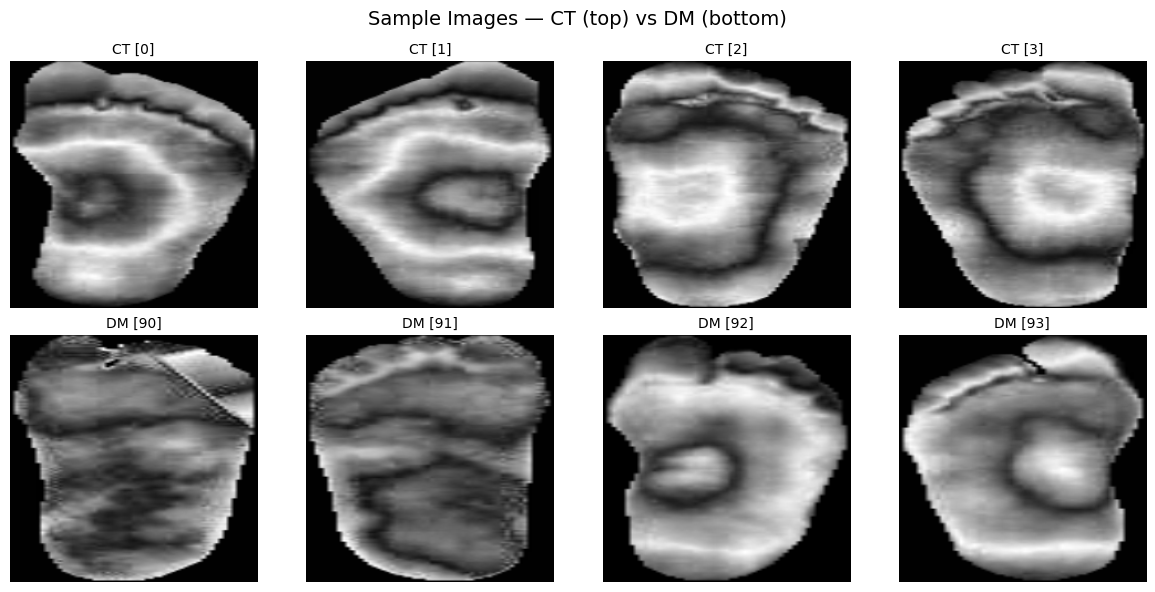

In [40]:
ct_idx = np.where(y == 0)[0][:4]
dm_idx = np.where(y == 1)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Sample Images — CT (top) vs DM (bottom)', fontsize=14)
for i, idx in enumerate(ct_idx):
    axes[0, i].imshow(X[idx])
    axes[0, i].set_title(f'CT [{idx}]', fontsize=10)
    axes[0, i].axis('off')
for i, idx in enumerate(dm_idx):
    axes[1, i].imshow(X[idx])
    axes[1, i].set_title(f'DM [{idx}]', fontsize=10)
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

Train+Val : 267  (CT=72, DM=195)
Test set  : 67  (CT=18, DM=49)

  Fold 1: train=213 (CT=57, DM=156)  val=54 (CT=15, DM=39)
  Fold 2: train=213 (CT=57, DM=156)  val=54 (CT=15, DM=39)
  Fold 3: train=214 (CT=58, DM=156)  val=53 (CT=14, DM=39)
  Fold 4: train=214 (CT=58, DM=156)  val=53 (CT=14, DM=39)
  Fold 5: train=214 (CT=58, DM=156)  val=53 (CT=14, DM=39)


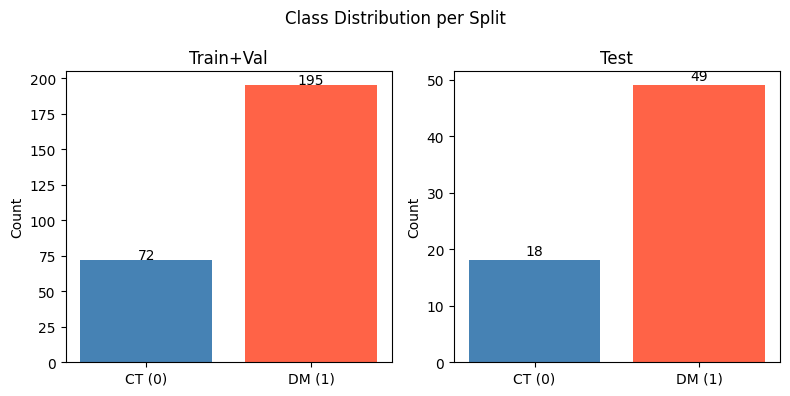

In [41]:
fold_indices, test_indices = create_fold_splits(
    X, y,
    n_splits=CONFIG['n_folds'],
    test_split=CONFIG['test_split'],
)

train_mask = np.ones(len(y), dtype=bool)
train_mask[test_indices] = False
y_trainval = y[train_mask]
y_test     = y[test_indices]

print(f'Train+Val : {len(y_trainval)}  (CT={(y_trainval==0).sum()}, DM={(y_trainval==1).sum()})')
print(f'Test set  : {len(y_test)}  (CT={(y_test==0).sum()}, DM={(y_test==1).sum()})')
print()
for fi in fold_indices:
    ytr = y[fi['train_idx']]
    yv  = y[fi['val_idx']]
    print(f"  Fold {fi['fold']+1}: train={len(ytr)} (CT={( ytr==0).sum()}, DM={(ytr==1).sum()})  "
          f"val={len(yv)} (CT={(yv==0).sum()}, DM={(yv==1).sum()})")

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for split_i, (yl, title) in enumerate([(y_trainval, 'Train+Val'), (y_test, 'Test')]):
    counts = [(yl==0).sum(), (yl==1).sum()]
    ax[split_i].bar(['CT (0)', 'DM (1)'], counts, color=['steelblue', 'tomato'])
    ax[split_i].set_title(title)
    ax[split_i].set_ylabel('Count')
    for j, v in enumerate(counts):
        ax[split_i].text(j, v + 1, str(v), ha='center')
plt.suptitle('Class Distribution per Split')
plt.tight_layout()
plt.show()

---
## 2. Model Architecture (CNN)

```
Input (224×224×3)
    ↓
Backbone (ImageNet pretrained, frozen in Phase 1)
    ↓
GlobalAveragePooling2D
    ↓
Dense(n₁, relu) + L2 → Dropout
    ↓
Dense(n₂, relu) + L2 → Dropout
    ↓
Dense(1, sigmoid)
```

> n₁, n₂, dropout, L2, and learning rates are determined by **Optuna** (Section 3)

| Phase | Backbone | Max Epochs | Early Stop | LR |
|-------|----------|-----------|-----------|----|
| 1 | Frozen | 50 | patience=5 (val_loss) | 1e-4 – 1e-2 (Optuna) |
| 2 | Unfreeze top 30% | 50 | patience=15 (val_loss) | 1e-6 – 1e-4, Exp decay (Optuna) |

---
## 3. Training

Each backbone is trained with **Optuna** hyperparameter search (10 trials on Fold 1) followed by **5-fold CV**.  
Outputs saved to `model_checkpoints/`: `best_params.json`, `val_preds.npz`, `avg_epochs.json`

- **Resume-aware**: existing checkpoints are loaded automatically — only missing folds are retrained.
- Delete files in `model_checkpoints/` to force a full retrain.


In [44]:
MODELS = ['EfficientNetB0', 'ResNet50', 'ConvNeXt-Tiny']
ARTIFACTS = ['val_preds.npz', 'best_params.json', 'avg_epochs.json']

print(f"{'Model':<18} {'val_preds':>12} {'best_params':>12} {'avg_epochs':>12}")
print('-' * 58)
for m in MODELS:
    row = ['✓' if (CKPT_DIR / f'{m}_{art}').exists() else '✗' for art in ARTIFACTS]
    print(f"{m:<18} {row[0]:>12} {row[1]:>12} {row[2]:>12}")

Model                 val_preds  best_params   avg_epochs
----------------------------------------------------------
EfficientNetB0                ✓            ✓            ✓
ResNet50                      ✓            ✓            ✓
ConvNeXt-Tiny                 ✓            ✓            ✓


In [45]:
BACKBONE_SCRIPTS = {
    'EfficientNetB0': 'train_efficientnet.py',
    'ResNet50':       'train_resnet.py',
    'ConvNeXt-Tiny':  'train_convnext.py',
}

for model_name, script in BACKBONE_SCRIPTS.items():
    all_done = all(
        (CKPT_DIR / f'{model_name}_{art}').exists()
        for art in ['val_preds.npz', 'best_params.json', 'avg_epochs.json']
    )
    if all_done:
        print(f'✓ {model_name} — already trained, skipping.')
        continue

    print(f'\n{"="*60}')
    print(f'Training {model_name} ...')
    print(f'{"="*60}')

    proc = subprocess.Popen(
        ['bash', 'run_gpu.sh', script],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1, cwd=str(PROJECT_DIR),
    )
    for line in proc.stdout:
        print(line, end='', flush=True)
    proc.wait()

    if proc.returncode == 0:
        print(f'\n✓ {model_name} training complete.')
    else:
        print(f'\n✗ {model_name} failed (exit code {proc.returncode})')
        break

✓ EfficientNetB0 — already trained, skipping.
✓ ResNet50 — already trained, skipping.
✓ ConvNeXt-Tiny — already trained, skipping.


### Proposed Model Architecture — All Backbones (actual hyperparameters from Optuna)

In [ ]:
from dfu_common import DFUModelTrainer, base_model_creators
from IPython.display import display as ipy_display

creators  = base_model_creators()
backbones = ['EfficientNetB0', 'ResNet50', 'ConvNeXt-Tiny']

for backbone_name in backbones:
    bp_path = CKPT_DIR / f'{backbone_name}_best_params.json'
    if not bp_path.exists():
        print(f"⚠ {backbone_name}: best_params.json not found — run training first")
        continue
    with open(bp_path) as f:
        bp = json.load(f)

    print(f"\n{'='*60}")
    print(f"Backbone: {backbone_name}")
    print(f"  dense_units=({bp['dense_units_1']}, {bp['dense_units_2']}), dropout={bp['dropout_rate']:.3f}")
    print(f"{'='*60}")

    base_model = creators[backbone_name]()
    trainer = DFUModelTrainer(
        backbone_name, base_model,
        dropout_rate=bp['dropout_rate'],
        l2_reg=bp['l2_reg'],
        dense_units=(bp['dense_units_1'], bp['dense_units_2']),
    )
    trainer.build_model()

    img_path = str(RESULTS_DIR / f'model_{backbone_name.replace("-","_")}.png')
    try:
        tf.keras.utils.plot_model(
            trainer.model, to_file=img_path,
            show_shapes=True, show_layer_names=True,
            expand_nested=False, dpi=96,
        )
        ipy_display(Image.open(img_path))
    except Exception as e:
        print(f"plot_model failed: {e}")
        trainer.model.summary(line_length=80)

---
## 4. RQ1 — Backbone Comparison

**Objective**: Select the best backbone from 3 candidates using 5-fold CV on the training set.

**Clinical screening criteria** (all three must be met):
- AUC-ROC ≥ 0.80
- Sensitivity ≥ 0.85
- Specificity ≥ 0.70

Results saved to: `results/rq1_results.json`


In [46]:
rq1_json = RESULTS_DIR / 'rq1_results.json'
if rq1_json.exists():
    print('rq1_results.json already exists — skipping re-run.')
    print('Delete the file if you want to re-run.')
else:
    print('Running rq1_backbone_comparison.py ...')
    rc = run_script('rq1_backbone_comparison.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

rq1_results.json already exists — skipping re-run.
Delete the file if you want to re-run.


Best backbone: ConvNeXt-Tiny



,Backbone,AUC,Sensitivity,Specificity,Qualifies
0,EfficientNetB0,0.6379,0.5949,0.4181,False
1,ResNet50,0.7875,0.9897,0.1533,False
2,ConvNeXt-Tiny,0.8390,0.7846,0.6657,False


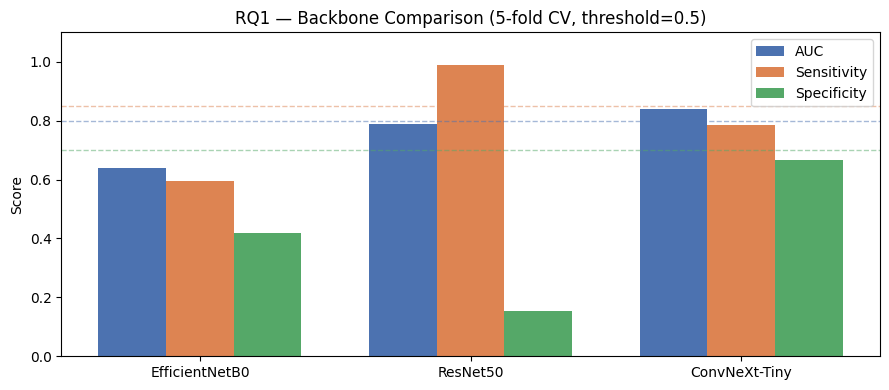

Winner: ConvNeXt-Tiny (AUC=0.8390)


In [47]:
if not rq1_json.exists():
    print(f'rq1_results.json not found. Run cell above first.')
else:
    with open(rq1_json) as f:
        rq1 = json.load(f)

    rows = []
    for entry in rq1['comparison']:
        rows.append({
            'Backbone':    entry['name'],
            'AUC':         round(entry['auc'],  4),
            'Sensitivity': round(entry['sens'], 4),
            'Specificity': round(entry['spec'], 4),
            'Qualifies':   entry['qualifies'],
        })
    df_rq1 = pd.DataFrame(rows)

    print(f"Best backbone: {rq1['best_model']}")
    print()
    display(df_rq1)

    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(df_rq1))
    w = 0.25
    colors = ['#4C72B0', '#DD8452', '#55A868']
    for i, (m, c) in enumerate(zip(['AUC', 'Sensitivity', 'Specificity'], colors)):
        ax.bar(x + i*w, df_rq1[m], w, label=m, color=c)
    for thr, c in zip([0.80, 0.85, 0.70], colors):
        ax.axhline(thr, color=c, linestyle='--', alpha=0.5, linewidth=1)
    ax.set_xticks(x + w)
    ax.set_xticklabels(df_rq1['Backbone'])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title('RQ1 — Backbone Comparison (5-fold CV, threshold=0.5)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    best_auc = df_rq1.loc[df_rq1['Backbone'] == rq1['best_model'], 'AUC'].values[0]
    print(f"Winner: {rq1['best_model']} (AUC={best_auc:.4f})")

---
## 5. Threshold Optimization (Youden's Index)

$$J = \text{Sensitivity} + \text{Specificity} - 1 \quad \Rightarrow \quad \text{thr}^* = \arg\max(\text{TPR} - \text{FPR})$$

**Step 1**: Compute per-fold Youden threshold → take the mean across folds  
**Step 2**: Apply the mean threshold to each fold's validation set and compare against default 0.5

Results saved to: `results/threshold_results.json`

In [48]:
thr_json = RESULTS_DIR / 'threshold_results.json'
if thr_json.exists():
    print('threshold_results.json already exists — skipping re-run.')
else:
    print('Running threshold_optimization.py ...')
    rc = run_script('threshold_optimization.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

threshold_results.json already exists — skipping re-run.


Best model        : ConvNeXt-Tiny
Mean Youden thr   : 0.6929 ± 0.2880

Per-fold Youden thresholds:


,fold,youden_threshold,youden_sens,youden_spec
0,1,0.886009,0.692308,0.866667
1,2,0.342344,0.871795,0.733333
2,3,0.937763,0.564103,0.928571
3,4,0.957788,0.589744,0.928571
4,5,0.340355,0.948718,0.857143



Comparison: Default 0.5 vs Youden threshold


,Threshold,Sensitivity,Specificity
0,Default 0.5,0.7846 ± 0.0205,0.6657 ± 0.1400
1,Youden 0.6929,0.7231 ± 0.0377,0.7352 ± 0.0850



Δ Sensitivity : -0.0615 pp  (-7.8%)
Δ Specificity : +0.0695 pp  (+10.4%)


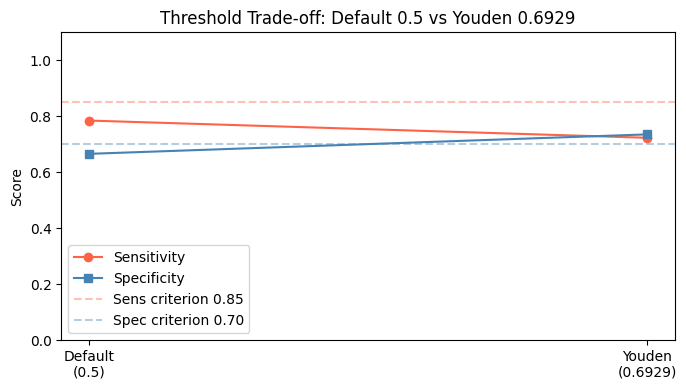

In [49]:
if not thr_json.exists():
    print('threshold_results.json not found. Run cell above first.')
else:
    with open(thr_json) as f:
        thr = json.load(f)

    mean_thr = thr['mean_youden_threshold']
    d = thr['default_threshold']
    y_ = thr['youden_threshold']

    print(f"Best model        : {thr['best_model']}")
    print(f"Mean Youden thr   : {mean_thr:.4f} ± {thr['std_youden_threshold']:.4f}")
    print()
    print('Per-fold Youden thresholds:')
    display(pd.DataFrame(thr['per_fold_thresholds']))

    print()
    print('Comparison: Default 0.5 vs Youden threshold')
    df_comp = pd.DataFrame([
        {'Threshold': 'Default 0.5',
         'Sensitivity': f"{d['mean_sens']:.4f} ± {d['std_sens']:.4f}",
         'Specificity': f"{d['mean_spec']:.4f} ± {d['std_spec']:.4f}"},
        {'Threshold': f"Youden {mean_thr:.4f}",
         'Sensitivity': f"{y_['mean_sens']:.4f} ± {y_['std_sens']:.4f}",
         'Specificity': f"{y_['mean_spec']:.4f} ± {y_['std_spec']:.4f}"},
    ])
    display(df_comp)

    delta_sens_pct = (thr['delta_sens_pp'] / d['mean_sens'] * 100) if d['mean_sens'] > 1e-9 else 0
    delta_spec_pct = (thr['delta_spec_pp'] / d['mean_spec'] * 100) if d['mean_spec'] > 1e-9 else 0
    print(f"\nΔ Sensitivity : {thr['delta_sens_pp']:+.4f} pp  ({delta_sens_pct:+.1f}%)")
    print(f"Δ Specificity : {thr['delta_spec_pp']:+.4f} pp  ({delta_spec_pct:+.1f}%)")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot([0.5, mean_thr], [d['mean_sens'], y_['mean_sens']], 'o-', label='Sensitivity', color='tomato')
    ax.plot([0.5, mean_thr], [d['mean_spec'], y_['mean_spec']], 's-', label='Specificity', color='steelblue')
    ax.axhline(0.85, color='tomato',    linestyle='--', alpha=0.4, label='Sens criterion 0.85')
    ax.axhline(0.70, color='steelblue', linestyle='--', alpha=0.4, label='Spec criterion 0.70')
    ax.set_xticks([0.5, mean_thr])
    ax.set_xticklabels([f'Default\n(0.5)', f"Youden\n({mean_thr:.4f})"])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title(f'Threshold Trade-off: Default 0.5 vs Youden {mean_thr:.4f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 6. Final Evaluation on Test Set

**Strategy**:
1. Load the average stopping epoch from 5-fold CV (`{model}_avg_epochs.json`)
2. Retrain on the **full training set** for exactly that many epochs — no early stopping
3. Evaluate on the held-out test set using the mean Youden threshold

Results saved to: `results/final_eval_results.json`, `results/final_eval_probs.npy`

In [50]:
cnn_json = RESULTS_DIR / 'final_eval_results.json'
if cnn_json.exists():
    print('final_eval_results.json already exists — skipping re-run.')
else:
    print('Running final_evaluation.py (retraining on full train set) ...')
    rc = run_script('final_evaluation.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

final_eval_results.json already exists — skipping re-run.


Model      : ConvNeXt-Tiny
Threshold  : 0.6929  (Youden)
Epochs     : phase1=50, phase2=47



,Metric,Value
0,Sensitivity,0.9184
1,Specificity,0.8333
2,PPV,0.9375
3,NPV,0.7895
4,F1-Score,0.9278
5,AUC-ROC,0.9070


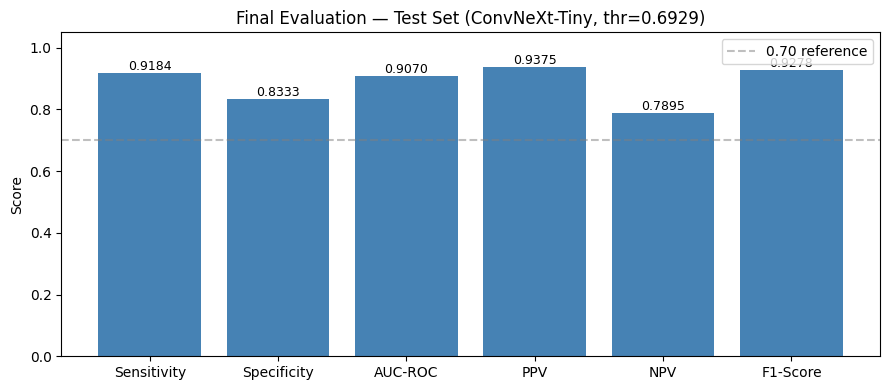

In [51]:
if not cnn_json.exists():
    print('final_eval_results.json not found. Run cell above first.')
else:
    with open(cnn_json) as f:
        cnn = json.load(f)

    m = cnn['test_metrics']
    print(f"Model      : {cnn['best_model']}")
    print(f"Threshold  : {cnn['threshold']:.4f}  (Youden)")
    print(f"Epochs     : phase1={cnn['retrain_epochs']['phase1']}, phase2={cnn['retrain_epochs']['phase2']}")
    print()

    metric_labels = {
        'sensitivity': 'Sensitivity',
        'specificity': 'Specificity',
        'auc_roc':     'AUC-ROC',
        'ppv':         'PPV',
        'npv':         'NPV',
        'f1':          'F1-Score',
    }
    df_cnn = pd.DataFrame([
        {'Metric': metric_labels[k], 'Value': round(v, 4)}
        for k, v in m.items() if k in metric_labels
    ])
    display(df_cnn)

    metrics_plot = list(metric_labels.values())
    values_plot  = [m[k] for k in metric_labels]

    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['tomato' if v < 0.70 else 'steelblue' for v in values_plot]
    bars = ax.bar(metrics_plot, values_plot, color=colors)
    ax.axhline(0.70, color='gray', linestyle='--', alpha=0.5, label='0.70 reference')
    for bar, v in zip(bars, values_plot):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(f"Final Evaluation — Test Set ({cnn['best_model']}, thr={cnn['threshold']:.4f})")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 7. RQ2 — Explainability (Grad-CAM / Grad-CAM++ / Eigen-CAM)

| Method | Concept |
|--------|---------|
| **Grad-CAM** | Weight feature maps by global-avg-pooled gradients |
| **Grad-CAM++** | Alpha weights derived from 2nd-order gradients |
| **Eigen-CAM** | Gradient-free — PC1 from SVD of the feature map |

Output: 4-panel images saved to `results/rq2_gradcam/`

> **Note**: Pointing Game evaluation is deferred — the INAOE dataset does not include ground-truth ROI annotations.

In [52]:
rq2_cam_dir = RESULTS_DIR / 'rq2_gradcam'

if rq2_cam_dir.exists() and list(rq2_cam_dir.glob('*.png')):
    print(f'rq2_gradcam/ already has {len(list(rq2_cam_dir.glob("*.png")))} images — skipping re-run.')
else:
    print('Running rq2_gradcam.py ...')
    rc = run_script('rq2_gradcam.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

rq2_gradcam/ already has 8 images — skipping re-run.


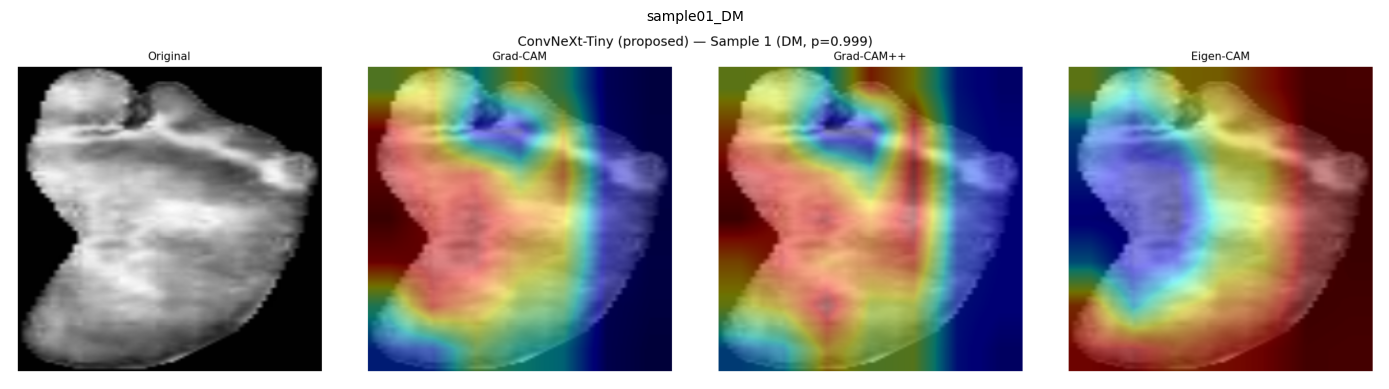

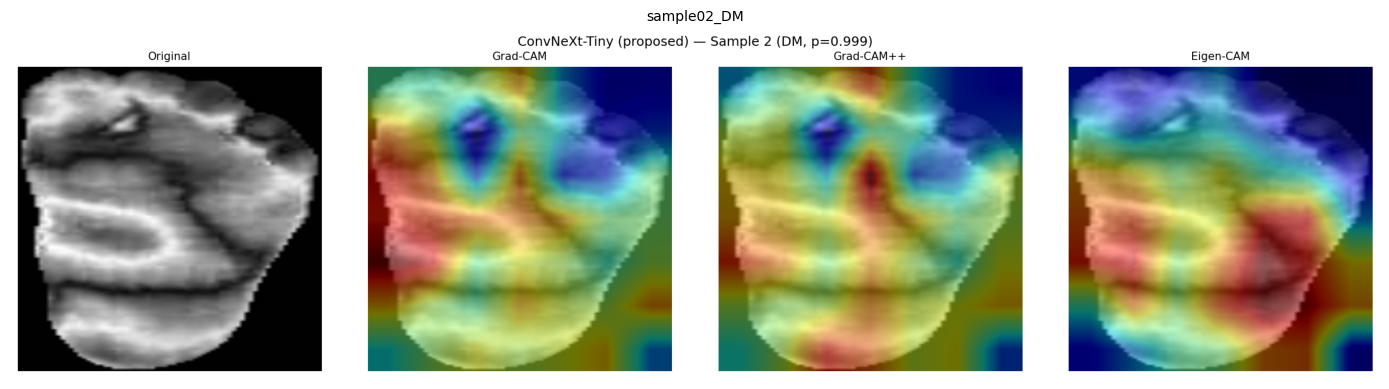

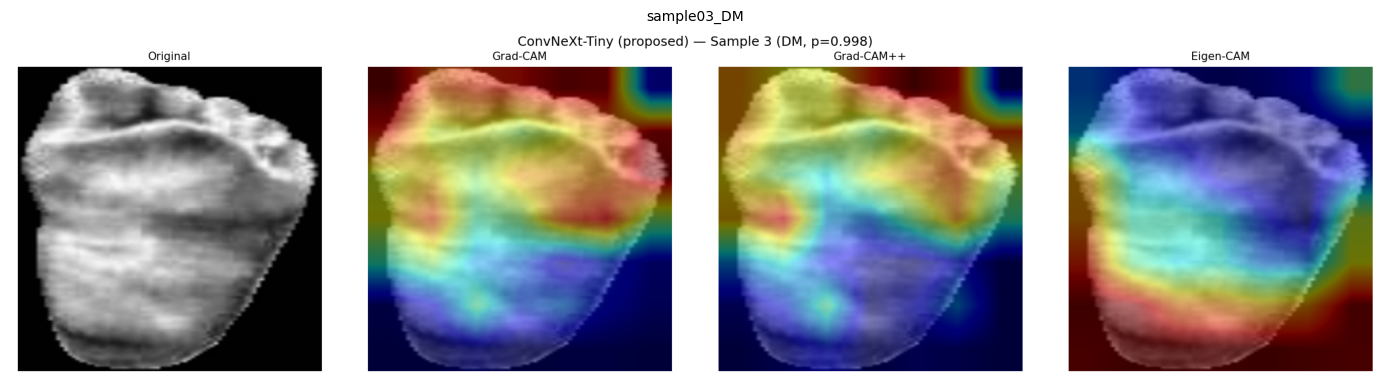

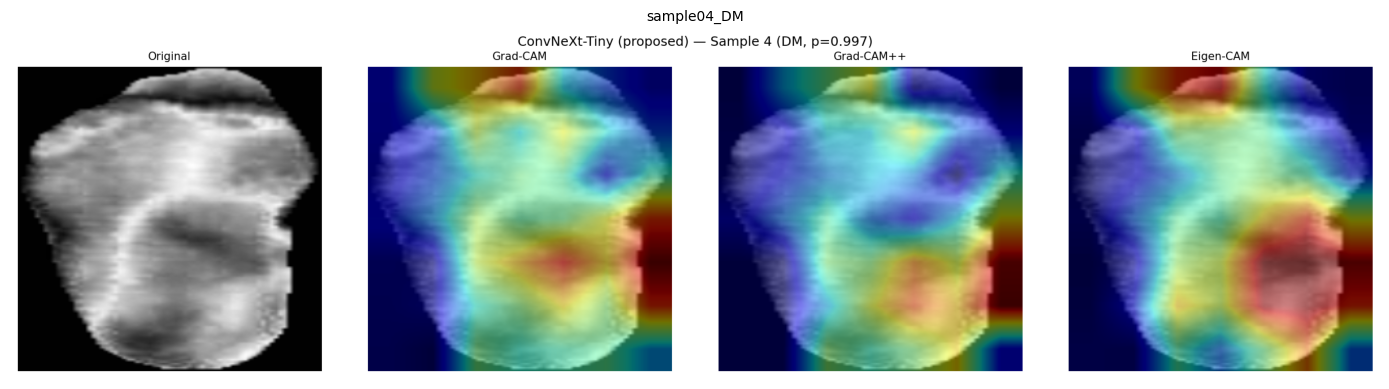

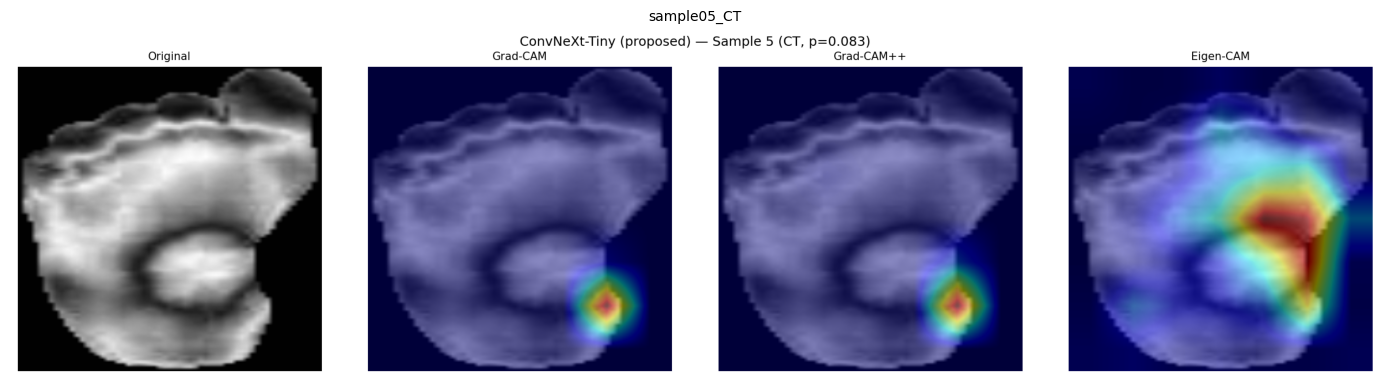

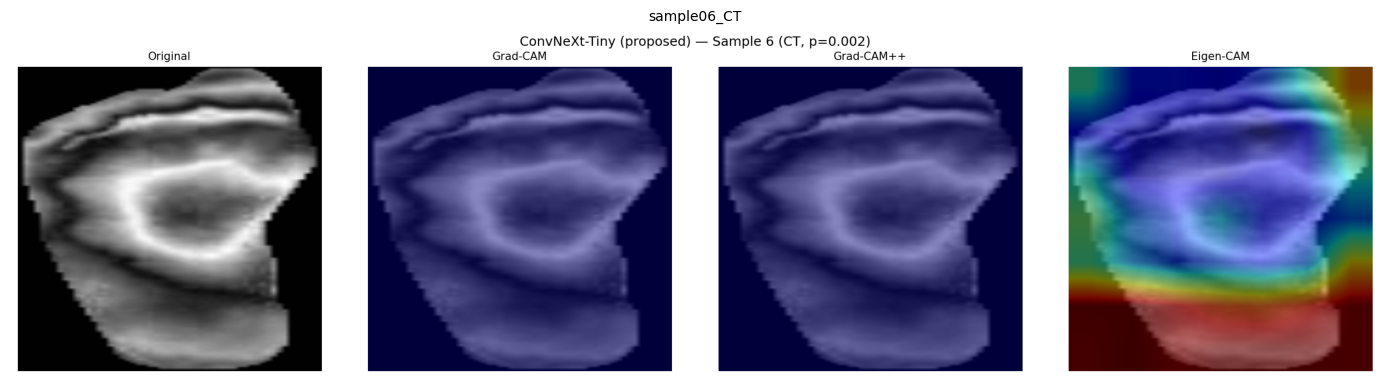

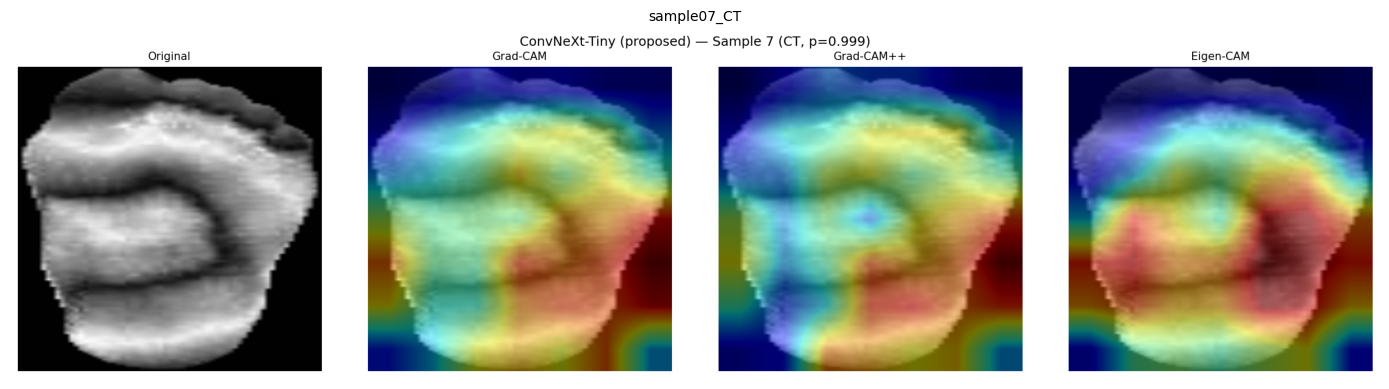

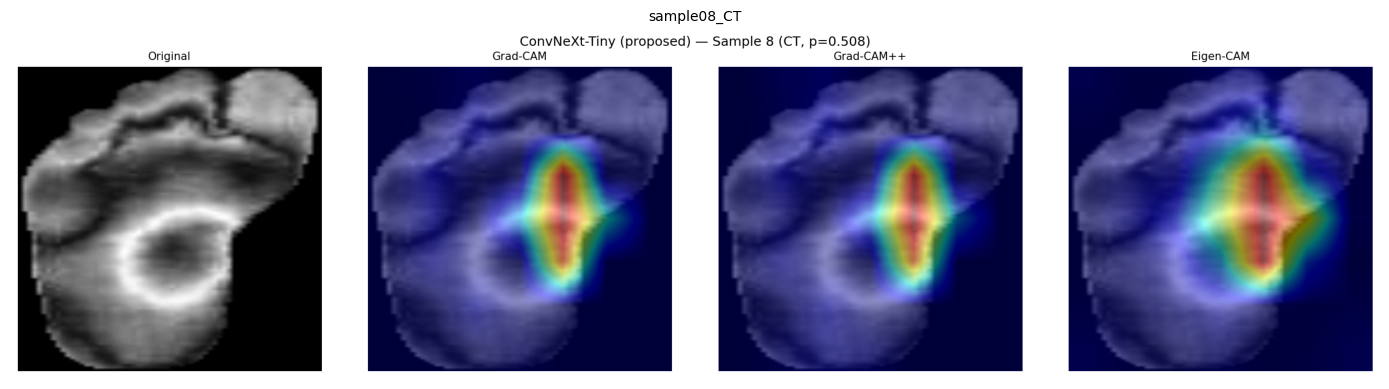

In [53]:
cam_images = sorted((RESULTS_DIR / 'rq2_gradcam').glob('*.png'))

if cam_images:
    for img_path in cam_images:
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.imshow(Image.open(img_path))
        ax.set_title(img_path.stem, fontsize=10)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print('No Grad-CAM images found.')

---
## 8. RQ3 — Proposed Model vs Baseline (BPNN)

**BPNN Feature Extraction (24-dim)**:

| Features | Details | Dim |
|----------|---------|-----|
| GLCM | 8-level quantized, 4 angles (0/45/90/135°), 4 properties × 4 angles | 16 |
| HOG | 8×8 cells, 8 statistics (mean, std, var, median, max, min, skew, kurt) | 8 |
| **Total** | | **24** |

**Baseline Hyperparameter Tuning (GridSearchCV)**:
- 5-fold CV, scoring = AUC-ROC
- Search space: `hidden_layer_sizes` ∈ {(64,32), (128,64), (256,128)}, `alpha` ∈ {1e-4, 1e-3, 1e-2}
- Fixed: activation=tanh, solver=Adam

**Performance Evaluation**: Both models are evaluated on the same held-out test set (67 images) using:
- Sensitivity, Specificity, AUC-ROC, PPV, NPV, F1-Score
- Each model uses its own Youden threshold (Proposed: from CV, Baseline: from GridSearchCV CV)

**Statistical Tests**:
- **McNemar's Test** — H₀: both models make the same classification errors
- **DeLong's Test** — H₀: AUC of Proposed Model = AUC of Baseline

Results saved to: `results/rq3_results.json`

In [ ]:
bpnn_json = RESULTS_DIR / 'rq3_results.json'
if bpnn_json.exists():
    print('rq3_results.json already exists — skipping re-run.')
else:
    print('Running rq3_bpnn_comparison.py ...')
    rc = run_script('rq3_bpnn_comparison.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

### Baseline BPNN Architecture (Best from GridSearchCV)

In [ ]:
rq3_json = RESULTS_DIR / 'rq3_results.json'
if not rq3_json.exists():
    print('rq3_results.json not found — run cell above first.')
else:
    with open(rq3_json) as f:
        bpnn_res = json.load(f)

    import ast, re
    arch_str    = bpnn_res['bpnn_architecture']
    sizes_match = re.search(r'\([\d,\s]+\)', arch_str)
    hidden_sizes = ast.literal_eval(sizes_match.group()) if sizes_match else (256, 128)

    print(f"Best BPNN architecture : {arch_str}")
    print(f"Hidden layer sizes     : {hidden_sizes}")

    def draw_bpnn_architecture(hidden_sizes):
        fig, ax = plt.subplots(figsize=(16, 4))
        ax.axis('off')

        box_w, box_h = 1.7, 0.85
        gap = 0.55

        layers = [
            ('Image\n224×224×3',       '',                    '#e0e7ff'),
            ('GLCM\n16-dim',           '8-level, 4 angles',   '#fef9c3'),
            ('HOG\n8-dim',             '8×8 cells, 8 stats',  '#fef9c3'),
            ('Feature Vector\n24-dim', 'StandardScaler',      '#fed7aa'),
        ]
        for i, size in enumerate(hidden_sizes):
            layers.append((f'Hidden {i+1}\n{size} (tanh)', '', '#fef9c3'))
        layers.append(('Output\n1', 'sigmoid', '#dcfce7'))

        xs      = [i * (box_w + gap) for i in range(len(layers))]
        total_w = xs[-1] + box_w
        xlim    = total_w + 1.5
        offset  = (xlim - total_w) / 2

        for i, (label, sublabel, color) in enumerate(layers):
            x    = offset + xs[i]
            y    = 1.3
            rect = plt.Rectangle((x, y), box_w, box_h, linewidth=1.5,
                                  edgecolor='#374151', facecolor=color, zorder=2)
            ax.add_patch(rect)
            ax.text(x + box_w/2, y + box_h * (0.65 if sublabel else 0.5),
                    label, ha='center', va='center', fontsize=8.5, fontweight='bold', zorder=3)
            if sublabel:
                ax.text(x + box_w/2, y + box_h * 0.22, sublabel,
                        ha='center', va='center', fontsize=7, color='#4b5563', zorder=3)
            if i < len(layers) - 1:
                ax.annotate('', xy=(offset + xs[i+1], y + box_h/2),
                            xytext=(x + box_w, y + box_h/2),
                            arrowprops=dict(arrowstyle='->', color='#374151', lw=1.5), zorder=3)

        x_left  = offset + xs[1]
        x_right = offset + xs[2] + box_w
        ax.annotate('', xy=(x_left, 2.35), xytext=(x_right, 2.35),
                    arrowprops=dict(arrowstyle='-', color='#6b7280', lw=1))
        ax.text((x_left + x_right) / 2, 2.52, 'Feature Extraction (handcrafted)',
                ha='center', va='center', fontsize=8, color='#6b7280', style='italic')

        ax.set_xlim(0, xlim)
        ax.set_ylim(0.8, 3.0)
        ax.set_title(f'Baseline BPNN Architecture — {arch_str}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    draw_bpnn_architecture(hidden_sizes)

In [ ]:
if not bpnn_json.exists():
    print('rq3_results.json not found. Run cell above first.')
elif not cnn_json.exists():
    print('final_eval_results.json not found. Run Final Evaluation section first.')
else:
    with open(bpnn_json) as f:
        bpnn = json.load(f)
    with open(cnn_json) as f:
        cnn_data = json.load(f)

    bpnn_m   = bpnn['test_metrics']
    cnn_m    = cnn_data['test_metrics']
    cnn_name = cnn_data['best_model']

    print(f"BPNN architecture : {bpnn['bpnn_architecture']}")
    print(f"Features          : {bpnn['features']}")
    print(f"Avg stopping iter : {bpnn['avg_stopping_iter']}  (per fold: {bpnn['fold_stopping_iters']})")
    print(f"Youden threshold  : {bpnn['mean_youden_threshold']:.4f}")
    print()

    order = ['sensitivity', 'specificity', 'auc_roc', 'ppv', 'npv', 'f1']
    labels_map = {'sensitivity': 'Sensitivity', 'specificity': 'Specificity',
                  'auc_roc': 'AUC-ROC', 'ppv': 'PPV', 'npv': 'NPV', 'f1': 'F1-Score'}
    df_rq3_bpnn = pd.DataFrame([
        {
            'Metric': labels_map[k],
            f'{cnn_name}': round(cnn_m[k], 4),
            'BPNN (GLCM+HOG)':  round(bpnn_m[k], 4),
            'Δ': round(cnn_m[k] - bpnn_m[k], 4),
        }
        for k in order
    ])
    display(df_rq3_bpnn)

    metrics_l = [labels_map[k] for k in order]
    cnn_vals  = [cnn_m[k]  for k in order]
    bpnn_vals = [bpnn_m[k] for k in order]
    x, w = np.arange(len(metrics_l)), 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w/2, cnn_vals,  w, label=f'{cnn_name} (CNN)', color='steelblue')
    ax.bar(x + w/2, bpnn_vals, w, label='BPNN (GLCM+HOG)',   color='tomato')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_l)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title('RQ3 — CNN vs BPNN Performance on Test Set')
    ax.legend()
    for i, (cv, bv) in enumerate(zip(cnn_vals, bpnn_vals)):
        ax.text(i - w/2, cv + 0.01, f'{cv:.3f}', ha='center', fontsize=8)
        ax.text(i + w/2, bv + 0.01, f'{bv:.3f}', ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    st = bpnn.get('statistical_tests', {})
    if st:
        cnn_thr = cnn_data['threshold']
        print(f"\nStatistical Tests  (CNN thr={cnn_thr:.4f}, BPNN thr={bpnn['mean_youden_threshold']:.4f})")
        print('─' * 60)
        mc  = st['mcnemar']
        auc = st['delong_auc']
        print(f"McNemar's test   H0: both classifiers make same errors")
        print(f"  b={mc['b']} (CNN correct / BPNN wrong)  c={mc['c']} (CNN wrong / BPNN correct)  "
              f"p={mc['p_value']:.4f} {mc['significance']}")
        print(f"DeLong's test    H0: AUC_CNN = AUC_BPNN (two-sided)")
        print(f"  ΔAUC={auc['delta_auc']:+.4f}  z={auc['z_stat']:.4f}  p={auc['p_value']:.4f} {auc['significance']}")
        print(f"\nSignificance: * p<0.05  ** p<0.01  *** p<0.001  ns = not significant")
    else:
        print("\nStatistical tests not available — re-run rq3_bpnn_comparison.py.")

---
## 9. Summary Dashboard

In [ ]:
required = [
    RESULTS_DIR / 'rq1_results.json',
    RESULTS_DIR / 'threshold_results.json',
    RESULTS_DIR / 'final_eval_results.json',
    RESULTS_DIR / 'rq3_results.json',
]
missing = [str(p) for p in required if not p.exists()]
if missing:
    print('Missing result files — run sections first:')
    for p in missing:
        print(f'  {p}')
else:
    with open(RESULTS_DIR / 'rq1_results.json') as f: rq1 = json.load(f)
    with open(RESULTS_DIR / 'threshold_results.json') as f: thr = json.load(f)
    with open(RESULTS_DIR / 'final_eval_results.json') as f: cnn = json.load(f)
    with open(RESULTS_DIR / 'rq3_results.json') as f: bpnn = json.load(f)

    best_name  = rq1['best_model']
    best_entry = next(e for e in rq1['comparison'] if e['name'] == best_name)
    cnn_m  = cnn['test_metrics']
    bpnn_m = bpnn['test_metrics']
    thr_y  = thr['youden_threshold']

    panels = [
        ('RQ1: Best Backbone\n(CV, thr=0.5)',
         best_entry['auc'], best_entry['sens'], best_entry['spec']),
        ('Threshold: Youden\n(CV)',
         0.0, thr_y['mean_sens'], thr_y['mean_spec']),
        (f'Final Eval: Test Set\n({best_name})',
         cnn_m['auc_roc'], cnn_m['sensitivity'], cnn_m['specificity']),
        ('RQ3: BPNN\n(GLCM+HOG)',
         bpnn_m['auc_roc'], bpnn_m['sensitivity'], bpnn_m['specificity']),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    for ax, (title, auc_, sens_, spec_) in zip(axes, panels):
        vals = [auc_, sens_, spec_]
        labs = ['AUC', 'Sens', 'Spec']
        cols = ['steelblue', 'tomato', 'seagreen']
        bars = ax.bar(labs, vals, color=cols)
        ax.axhline(0.80, color='steelblue', linestyle=':', alpha=0.5)
        ax.axhline(0.85, color='tomato',    linestyle=':', alpha=0.5)
        ax.axhline(0.70, color='seagreen',  linestyle=':', alpha=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                    ha='center', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_title(title, fontsize=10)

    plt.suptitle('Project Summary Dashboard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n=== Final Results ===")
    print(f"Best backbone      : {best_name} (AUC={best_entry['auc']:.4f})")
    print(f"Youden threshold   : {thr['mean_youden_threshold']:.4f}")
    print(f"Test Sensitivity   : {cnn_m['sensitivity']:.4f}")
    print(f"Test Specificity   : {cnn_m['specificity']:.4f}")
    print(f"Test AUC-ROC       : {cnn_m['auc_roc']:.4f}")
    print(f"BPNN AUC-ROC       : {bpnn_m['auc_roc']:.4f}")